In [1]:
import pandas as pd 
import numpy as np 
import matplotlib.pyplot as plt 
import seaborn as sns 

In [2]:
data = pd.read_csv("C:\\Users\\bingi\\Downloads\\Cusmtomer_data.csv")
df = data.copy()
df.head()

,Customer_ID,Customer_Name,Gender,Age,Marital_Status,Occupation,Annual_Income,Customer_Segment,State,City,Account_Type,Customer_Since
0,CUST100001,Omaja Majumdar,Female,27,Single,Police Officer,1167132,Gold,Uttar Pradesh,Agra,Savings,2017-11-13
1,CUST100002,Jason Agrawal,Female,41,Married,Teacher,493532,Standard,Madhya Pradesh,Ujjain,Salary,2020-05-05
2,CUST100003,Amrita Dora,Male,61,Divorsed,Business,1862614,Platinum,Assam,Silchar,Savings,2023-08-23
3,CUST100004,Radhika Batra,Male,26,Single,Software Engineer,808153,Gold,Uttar Pradesh,Ghaziabad,Salary,2018-05-21
4,CUST100005,Gautam Mukhopadhyay,Female,24,Single,Software Engineer,1581447,Platinum,Rajasthan,Jodhpur,Salary,2017-04-16


In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 25000 entries, 0 to 24999
Data columns (total 12 columns):
 #   Column            Non-Null Count  Dtype 
---  ------            --------------  ----- 
 0   Customer_ID       25000 non-null  object
 1   Customer_Name     25000 non-null  object
 2   Gender            25000 non-null  object
 3   Age               25000 non-null  int64 
 4   Marital_Status    25000 non-null  object
 5   Occupation        25000 non-null  object
 6   Annual_Income     25000 non-null  int64 
 7   Customer_Segment  25000 non-null  object
 8   State             25000 non-null  object
 9   City              25000 non-null  object
 10  Account_Type      25000 non-null  object
 11  Customer_Since    25000 non-null  object
dtypes: int64(2), object(10)
memory usage: 2.3+ MB


In [4]:
df.drop_duplicates()

,Customer_ID,Customer_Name,Gender,Age,Marital_Status,Occupation,Annual_Income,Customer_Segment,State,City,Account_Type,Customer_Since
0,CUST100001,Omaja Majumdar,Female,27,Single,Police Officer,1167132,Gold,Uttar Pradesh,Agra,Savings,2017-11-13
1,CUST100002,Jason Agrawal,Female,41,Married,Teacher,493532,Standard,Madhya Pradesh,Ujjain,Salary,2020-05-05
2,CUST100003,Amrita Dora,Male,61,Divorsed,Business,1862614,Platinum,Assam,Silchar,Savings,2023-08-23
3,CUST100004,Radhika Batra,Male,26,Single,Software Engineer,808153,Gold,Uttar Pradesh,Ghaziabad,Salary,2018-05-21
4,CUST100005,Gautam Mukhopadhyay,Female,24,Single,Software Engineer,1581447,Platinum,Rajasthan,Jodhpur,Salary,2017-04-16
...,...,...,...,...,...,...,...,...,...,...,...,...
24995,CUST124996,Onveer Kala,Male,22,Single,Nurse,740591,Gold,Odisha,Rourkela,Salary,2021-12-09
24996,CUST124997,Waida Dewan,Female,29,Single,Lawyer,3033538,Platinum,Karnataka,Bengaluru,Savings,2021-07-19
24997,CUST124998,Mohini Devi,Male,48,Married,Government Employee,1364078,Gold,West Bengal,Kolkata,Salary,2020-04-25
24998,CUST124999,Rishi Bahri,Male,52,Married,Farmer,324265,Standard,Odisha,Bhubaneswar,Savings,2021-12-27


In [5]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
Age,25000.0,4.180584e+01,1.306243e+01,18.0,31.0,41.0,52.0,70.0
Annual_Income,25000.0,1.611153e+06,1.727786e+06,2.0,570477.5,969189.0,1882414.0,9999931.0


In [6]:
Q1 = df['Annual_Income'].quantile(0.25)
Q3 = df['Annual_Income'].quantile(0.75)
IQR = Q3 - Q1

lower_bound = Q1 - 1.0*IQR
upper_bound = Q3 + 1.0*IQR

df_cleaned = df[(df['Annual_Income'] >= lower_bound) & (df['Annual_Income'] <= upper_bound)]
df_cleaned

,Customer_ID,Customer_Name,Gender,Age,Marital_Status,Occupation,Annual_Income,Customer_Segment,State,City,Account_Type,Customer_Since
0,CUST100001,Omaja Majumdar,Female,27,Single,Police Officer,1167132,Gold,Uttar Pradesh,Agra,Savings,2017-11-13
1,CUST100002,Jason Agrawal,Female,41,Married,Teacher,493532,Standard,Madhya Pradesh,Ujjain,Salary,2020-05-05
2,CUST100003,Amrita Dora,Male,61,Divorsed,Business,1862614,Platinum,Assam,Silchar,Savings,2023-08-23
3,CUST100004,Radhika Batra,Male,26,Single,Software Engineer,808153,Gold,Uttar Pradesh,Ghaziabad,Salary,2018-05-21
4,CUST100005,Gautam Mukhopadhyay,Female,24,Single,Software Engineer,1581447,Platinum,Rajasthan,Jodhpur,Salary,2017-04-16
...,...,...,...,...,...,...,...,...,...,...,...,...
24995,CUST124996,Onveer Kala,Male,22,Single,Nurse,740591,Gold,Odisha,Rourkela,Salary,2021-12-09
24996,CUST124997,Waida Dewan,Female,29,Single,Lawyer,3033538,Platinum,Karnataka,Bengaluru,Savings,2021-07-19
24997,CUST124998,Mohini Devi,Male,48,Married,Government Employee,1364078,Gold,West Bengal,Kolkata,Salary,2020-04-25
24998,CUST124999,Rishi Bahri,Male,52,Married,Farmer,324265,Standard,Odisha,Bhubaneswar,Savings,2021-12-27


In [7]:
df_cleaned.columns


Index(['Customer_ID', 'Customer_Name', 'Gender', 'Age', 'Marital_Status',
       'Occupation', 'Annual_Income', 'Customer_Segment', 'State', 'City',
       'Account_Type', 'Customer_Since'],
      dtype='object')

In [8]:
df_cleaned.drop(columns = 'Customer_ID',inplace = True)

C:\Users\bingi\AppData\Local\Temp\ipykernel_23888\3229367207.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_cleaned.drop(columns = 'Customer_ID',inplace = True)


C:\Users\bingi\AppData\Local\Temp\ipykernel_23888\1262192608.py:13: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df_cleaned, x=col, palette='Set2')
C:\Users\bingi\AppData\Local\Temp\ipykernel_23888\1262192608.py:13: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df_cleaned, x=col, palette='Set2')
C:\Users\bingi\AppData\Local\Temp\ipykernel_23888\1262192608.py:13: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df_cleaned, x=col, palette='Set2')
C:\Users\bingi\AppData\Local\Temp\ipykernel_23888\1262192608.py:13: FutureWarni

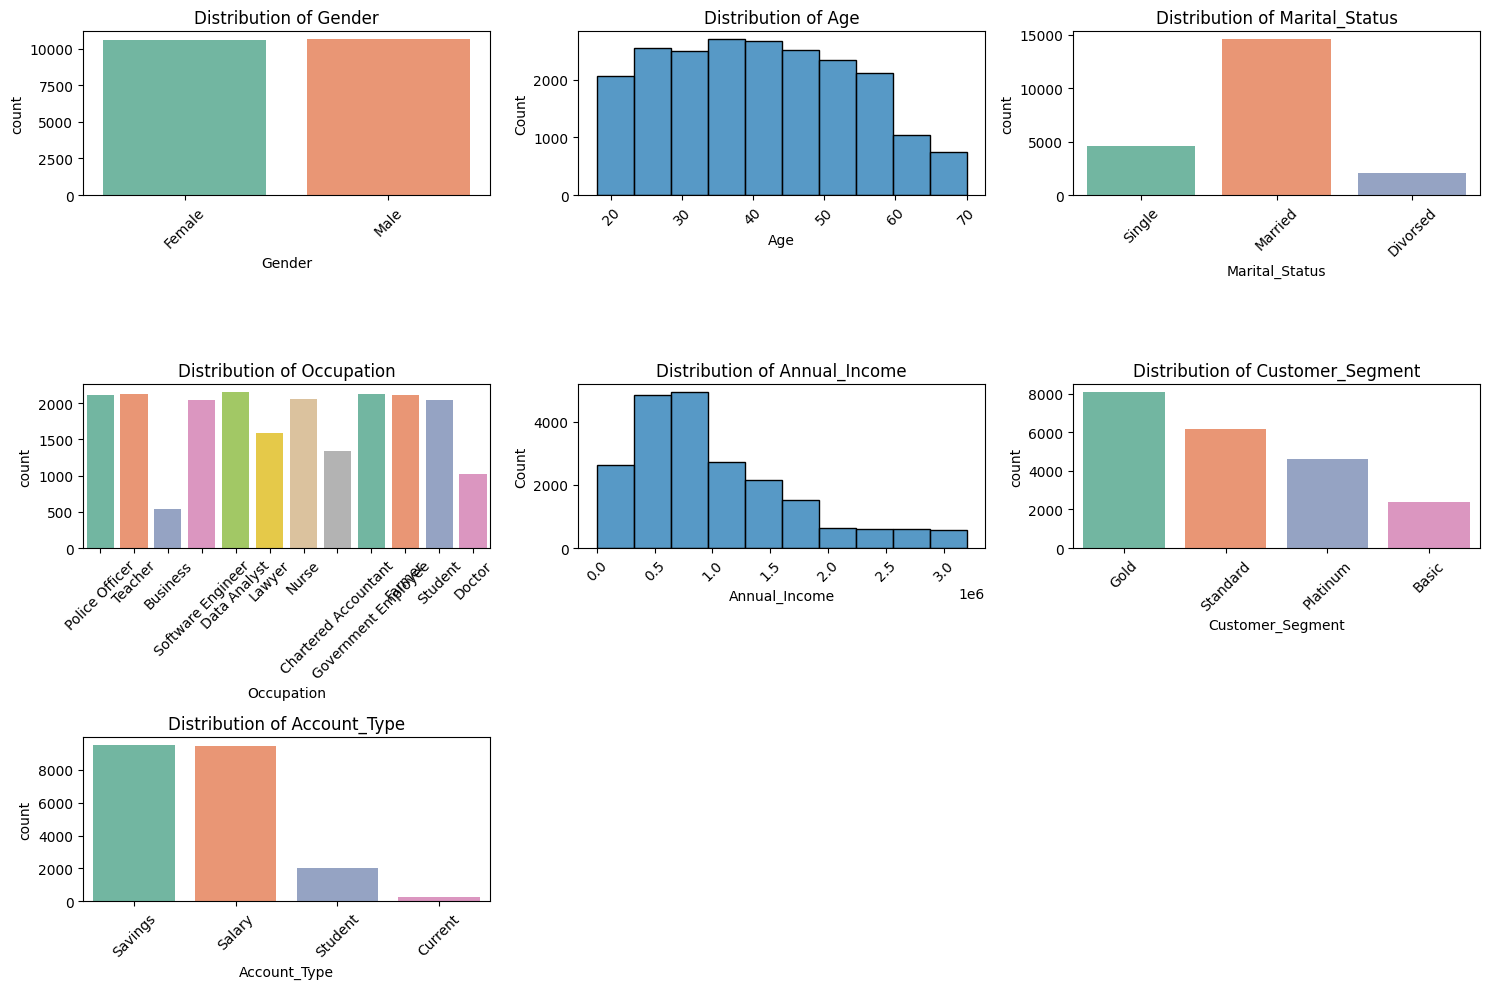

In [9]:
import matplotlib.pyplot as plt
import seaborn as sns

cols = ['Gender', 'Age', 'Marital_Status', 'Occupation',
        'Annual_Income', 'Customer_Segment', 'Account_Type']

plt.figure(figsize=(15,10))

for i, col in enumerate(cols):
    plt.subplot(3,3,i+1)
    
    if df_cleaned[col].dtype == 'object':  # categorical
        sns.countplot(data=df_cleaned, x=col, palette='Set2')
    else:
        sns.histplot(data = df_cleaned , x=col,edgecolor = 'black',bins = 10)
    
    plt.title(f'Distribution of {col}')
    plt.xticks(rotation=45)

plt.tight_layout()
plt.show()


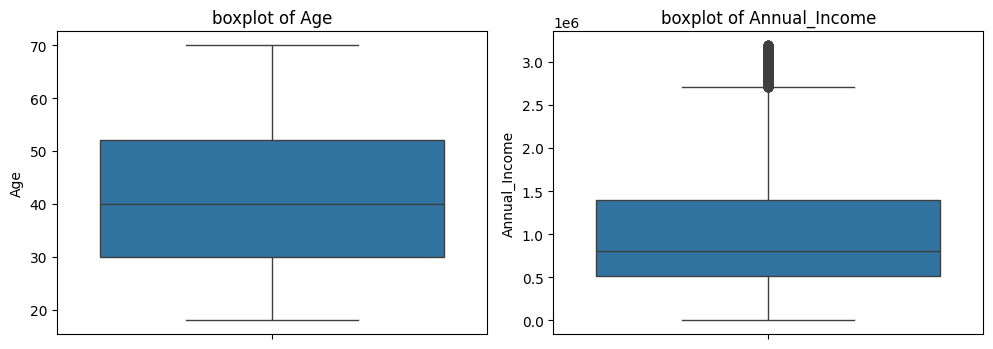

In [10]:
num_col = df_cleaned.select_dtypes(include = 'number').columns

plt.figure(figsize=(15,10))
for i,col in enumerate(num_col):
    plt.subplot(3,3,i+1)
    sns.boxplot(data = df_cleaned , y=col)
    plt.title(f'boxplot of {col}')

plt.tight_layout()
plt.show()

In [11]:
X = df_cleaned[['Occupation' , 'Annual_Income']]

In [12]:
from sklearn.preprocessing import LabelEncoder , StandardScaler

encoder = LabelEncoder()
X['Occupation'] = encoder.fit_transform(X['Occupation'])

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)


C:\Users\bingi\AppData\Local\Temp\ipykernel_23888\4225857584.py:4: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  X['Occupation'] = encoder.fit_transform(X['Occupation'])


In [13]:
from sklearn.cluster import KMeans

model = KMeans(
    n_clusters=3,        # number of clusters
    init='k-means++',    # smart centroid initialization
    max_iter=300,        # max iterations
    n_init=10,           # run multiple times
    random_state=42
)

model.fit(X_scaled)
df_cleaned['Cluster'] = model.labels_

C:\Users\bingi\AppData\Local\Temp\ipykernel_23888\1104040700.py:12: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_cleaned['Cluster'] = model.labels_


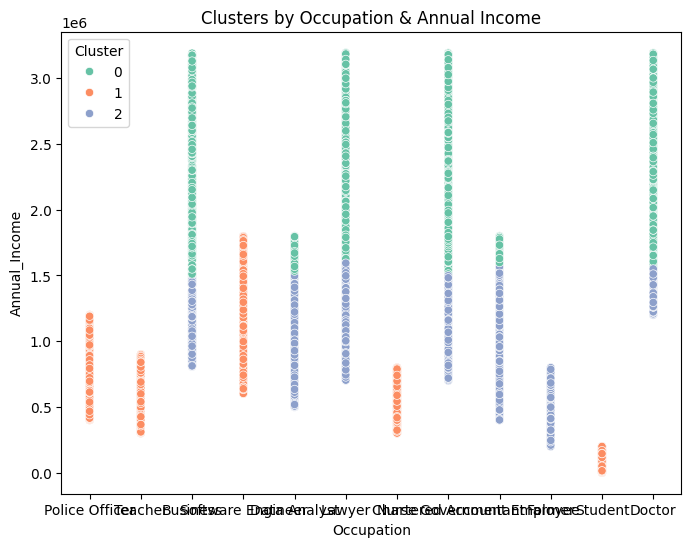

In [14]:
# Step 4: Visualize clusters
plt.figure(figsize=(8,6))
sns.scatterplot(
    data=df_cleaned,
    x='Occupation',
    y='Annual_Income',
    hue='Cluster',
    palette='Set2'
)

plt.title("Clusters by Occupation & Annual Income")

plt.show()

In [15]:
from sklearn.metrics import silhouette_score
score = silhouette_score(X_scaled, model.labels_)
print("Silhouette Score:", score)


Silhouette Score: 0.4518747534674315


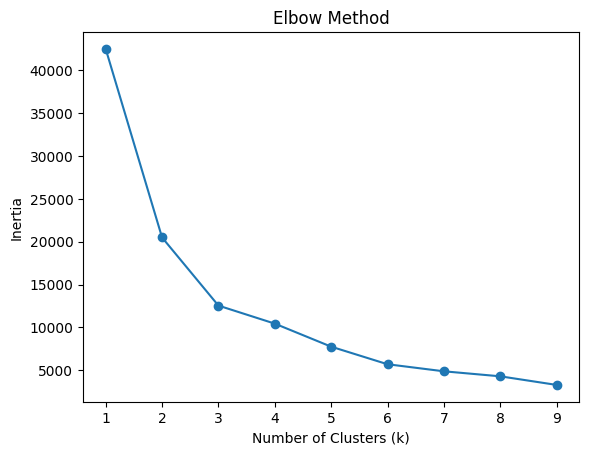

In [16]:
inertia = []
for k in range(1, 10):
    km = KMeans(n_clusters=k, random_state=42)
    km.fit(X_scaled)
    inertia.append(km.inertia_)       # it gives distance of centroids

plt.plot(range(1,10), inertia, marker='o')
plt.xlabel("Number of Clusters (k)")
plt.ylabel("Inertia")
plt.title("Elbow Method")
plt.show()


C:\Users\bingi\AppData\Local\Temp\ipykernel_23888\693098774.py:1: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='Cluster', y='Annual_Income', data=df_cleaned, palette='Set2')


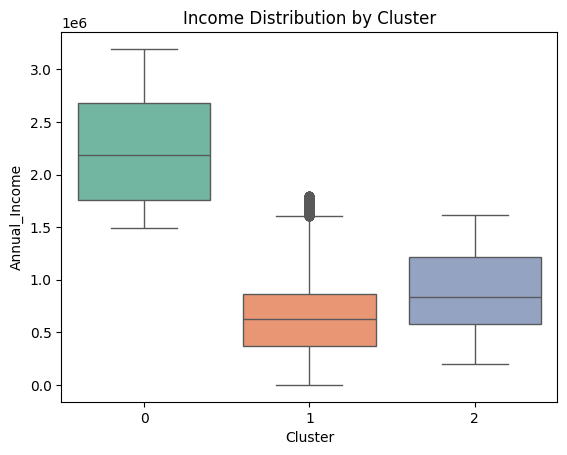

In [17]:
sns.boxplot(x='Cluster', y='Annual_Income', data=df_cleaned, palette='Set2')
plt.title("Income Distribution by Cluster")
plt.show()


In [18]:
X.head()

,Occupation,Annual_Income
0,8,1167132
1,11,493532
2,0,1862614
3,9,808153
4,9,1581447


In [19]:
import numpy as np
from sklearn.metrics import silhouette_score
from sklearn.cluster import MiniBatchKMeans


sample_size = min(1000, X.shape[0])
sample_idx = np.random.choice(X.shape[0], sample_size, replace=False)
X_sample = X.iloc[sample_idx]

silhouette_scores = {}
inertia = {}
K = range(2, 10)  # silhouette requires k >= 2

for k in K:
    kmeans = MiniBatchKMeans(n_clusters=k, init='k-means++', batch_size=1000, random_state=42)
    labels = kmeans.fit_predict(X)

    # Record inertia
    inertia[k] = kmeans.inertia_

    # Compute silhouette on sample only
    score = silhouette_score(X_sample, labels[sample_idx])
    silhouette_scores[k] = score

    print(f"k={k}, inertia={kmeans.inertia_:.0f}, silhouette score={score:.3f}")

# Best k (highest silhouette score)
best_k = max(silhouette_scores, key=silhouette_scores.get)
print(f"\nOptimal number of clusters based on silhouette score: k={best_k}")

k=2, inertia=3475891639624831, silhouette score=0.659
k=3, inertia=1564160408528686, silhouette score=0.595
k=4, inertia=930106103830090, silhouette score=0.540
k=5, inertia=611430449935715, silhouette score=0.544
k=6, inertia=414833987122466, silhouette score=0.543
k=7, inertia=296757070550160, silhouette score=0.547
k=8, inertia=221071934743822, silhouette score=0.550
k=9, inertia=179447133542476, silhouette score=0.547

Optimal number of clusters based on silhouette score: k=2


In [20]:
X

,Occupation,Annual_Income
0,8,1167132
1,11,493532
2,0,1862614
3,9,808153
4,9,1581447
...,...,...
24995,7,740591
24996,6,3033538
24997,5,1364078
24998,4,324265


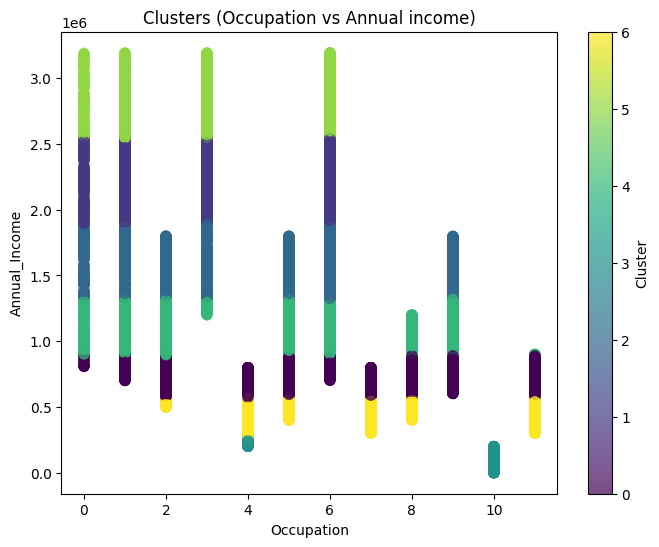

In [21]:
kmeans = MiniBatchKMeans(n_clusters=7, batch_size=1000, random_state=42)
labels = kmeans.fit_predict(X)

X = X.copy()
X['cluster'] = labels

plt.figure(figsize=(8,6))
plt.scatter(X['Occupation'], X['Annual_Income'], 
            c=X['cluster'], cmap='viridis', s=50, alpha=0.7)

plt.xlabel("Occupation")
plt.ylabel("Annual_Income")
plt.title("Clusters (Occupation vs Annual income)")
plt.colorbar(label='Cluster')
plt.show()

In [23]:
from sklearn.preprocessing import StandardScaler
X_scaled = StandardScaler().fit_transform(X)
pca = PCA(n_components=2)
X_reduced = pca.fit_transform(X_scaled)
print(pca.explained_variance_ratio_)


[0.50140871 0.3328551 ]


In [22]:
from sklearn.decomposition import PCA

# Initialize PCA with 2 components
pca = PCA(n_components=2)

# Fit PCA on your dataset (X should be your feature matrix)
X_reduced = pca.fit_transform(X_sample)

print("Explained variance ratio:", pca.explained_variance_ratio_)
print("Reduced shape:", X_reduced.shape)


Explained variance ratio: [1.00000000e+00 1.51579502e-11]
Reduced shape: (1000, 2)


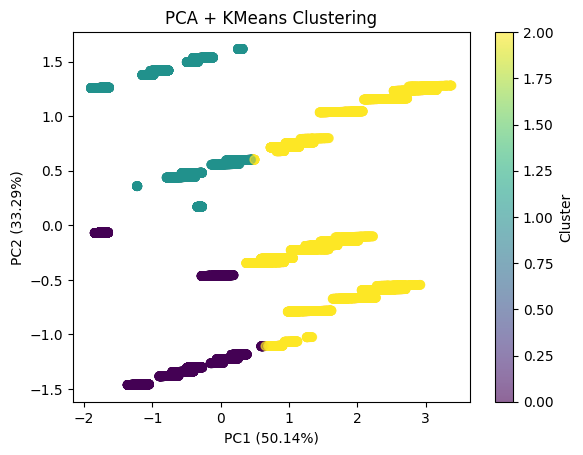

In [25]:
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler
import matplotlib.pyplot as plt

# 1. Scale the data
X_scaled = StandardScaler().fit_transform(X)

# 2. Apply PCA
pca = PCA(n_components=2)
X_reduced = pca.fit_transform(X_scaled)

# 3. Run KMeans on reduced data
kmeans = KMeans(n_clusters=3, random_state=42)  # adjust clusters
labels = kmeans.fit_predict(X_reduced)

# 4. Plot clusters
plt.scatter(X_reduced[:,0], X_reduced[:,1], c=labels, cmap='viridis', alpha=0.6)
plt.xlabel(f"PC1 ({pca.explained_variance_ratio_[0]:.2%})")
plt.ylabel(f"PC2 ({pca.explained_variance_ratio_[1]:.2%})")
plt.title("PCA + KMeans Clustering")
plt.colorbar(label="Cluster")
plt.show()


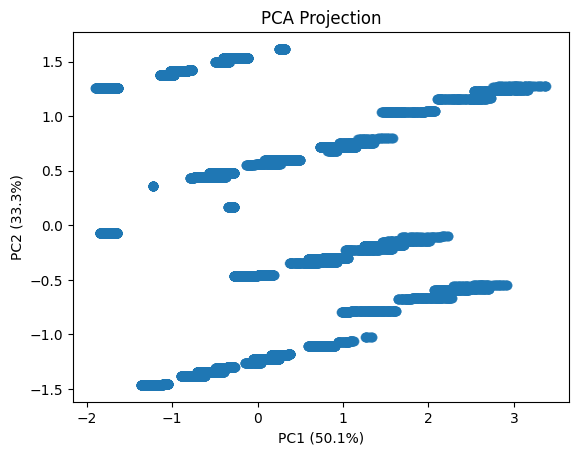

In [24]:
import matplotlib.pyplot as plt

plt.scatter(X_reduced[:,0], X_reduced[:,1], alpha=0.5)
plt.xlabel("PC1 (50.1%)")
plt.ylabel("PC2 (33.3%)")
plt.title("PCA Projection")
plt.show()
